# Loan Default Prediction — Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Loan_default.csv')
print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [3]:
df['Default'].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

## Target Variable

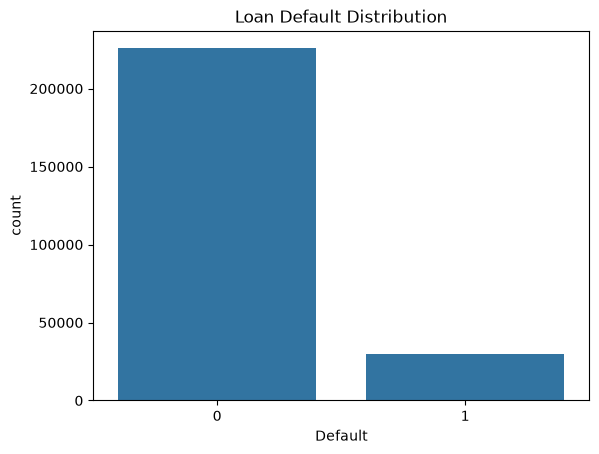

In [4]:
sns.countplot(x='Default',data=df)
plt.title('Loan Default Distribution')
plt.show()

The target variable is heavily imbalanced: **88.4% of loans did not default** (class 0)
and **11.6% defaulted** (class 1). This imbalance is expected in real-world lending data.
Accuracy alone will be a misleading evaluation metric.A model that always predicts
"no default" would score 88.4% accuracy while being completely useless. This will be
handled during modeling using class weighting, and evaluation will be based on ROC-AUC
and Precision-Recall metrics instead.

## Numeric Features

In [5]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('Default') #exclude the target itself from "features"
print(numeric_cols)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


In [6]:
df[numeric_cols].describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000


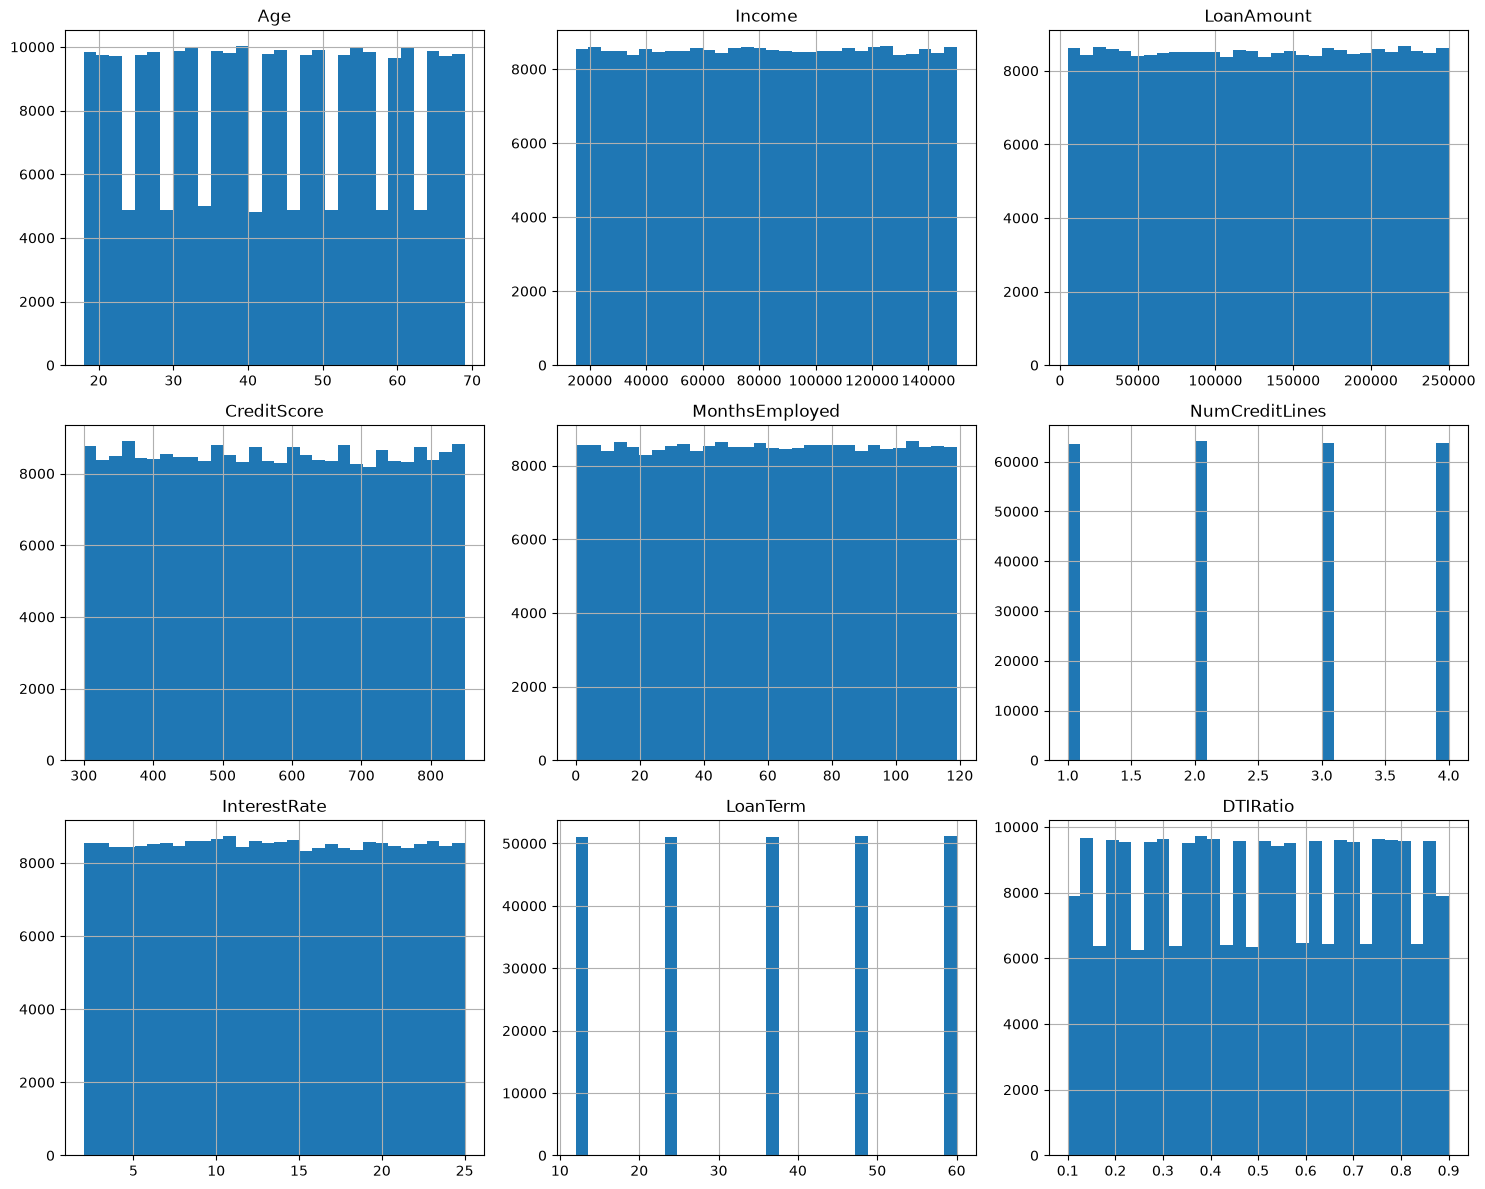

In [7]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

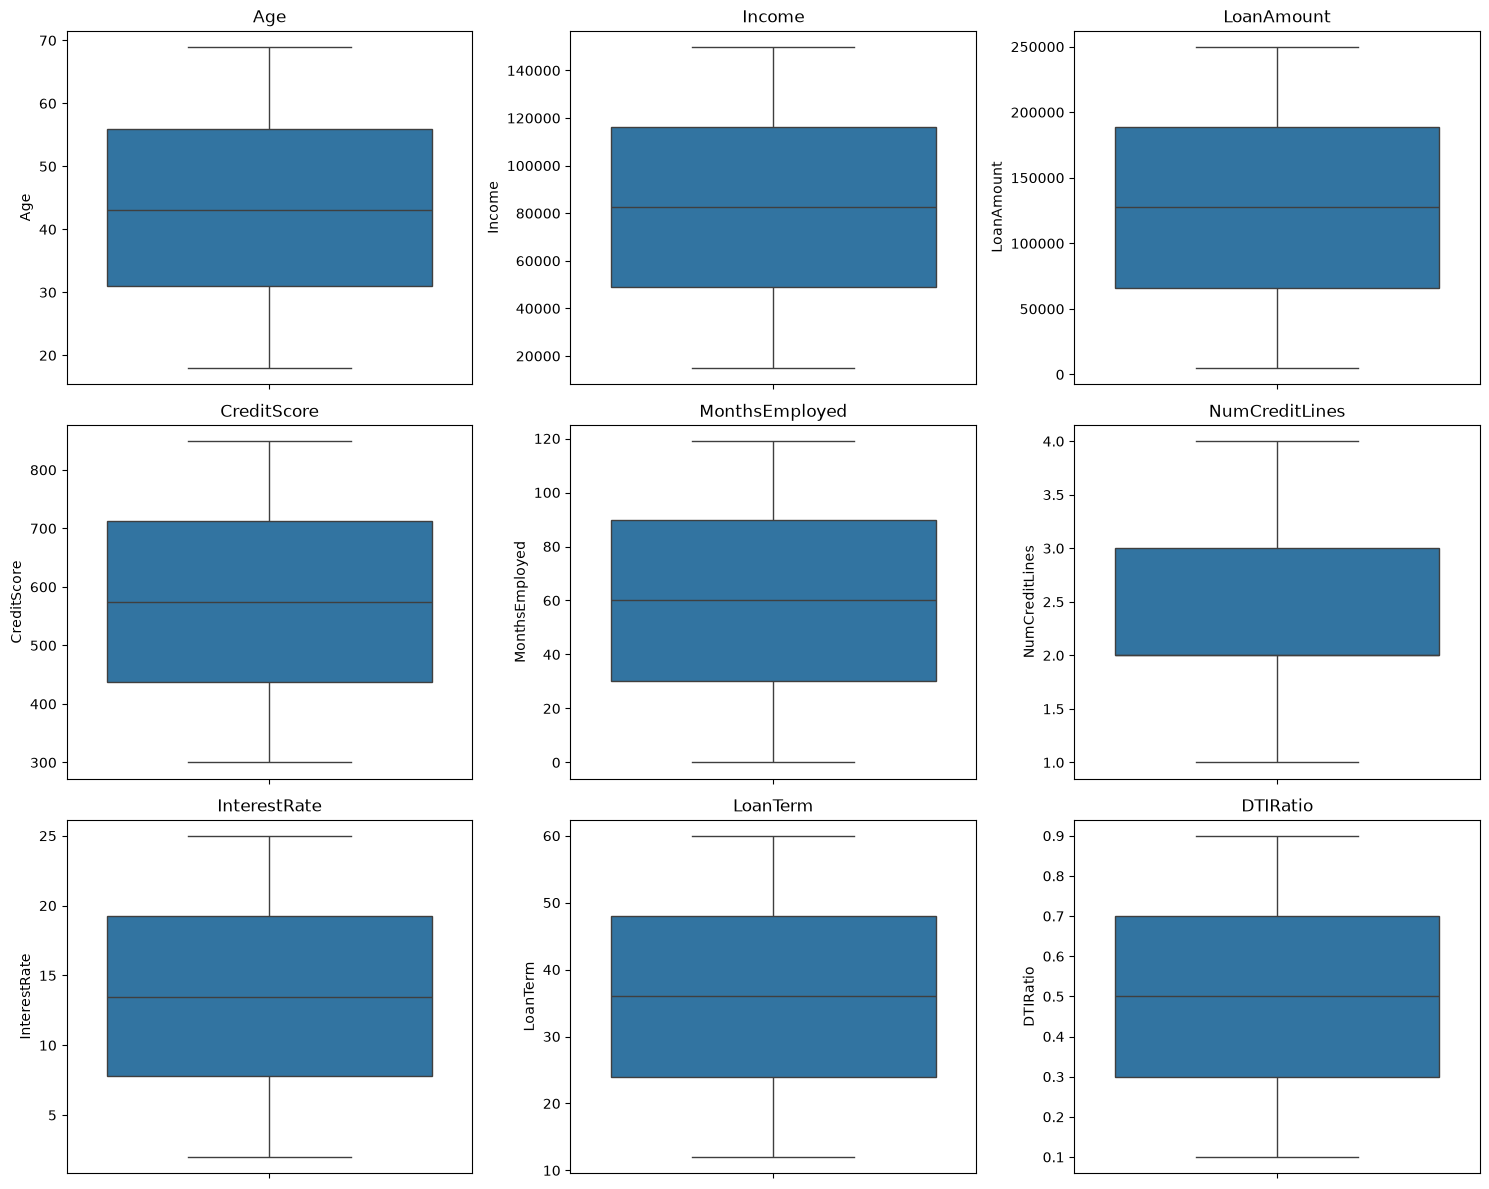

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Key Observations from Numeric Feature Distributions

**Distribution shape:** All numeric features follow a roughly uniform distribution as the
values are spread evenly across the entire range with no strong skew in any direction.
This is confirmed by the close agreement between mean and median for every column
(e.g., Age: mean 43.5 vs median 43, Income: mean 82,499 vs median 82,466).

**Outliers:** No outliers were detected in any numeric feature. The boxplots show no
data points beyond the whiskers for any column, meaning there are no extreme values
that could distort model training. As a result, no outlier treatment (capping or
removal) is required for this dataset.

**Notable feature types:** Two columns ,namely NumCreditLines and LoanTerm take only a
small number of distinct integer values (NumCreditLines: 1–4, LoanTerm: 12/24/36/48/60
months). Although stored as numeric columns, they behave more like ordinal categories.
This will be accounted for during the statistical testing and preprocessing stages.

## Categorical Features

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
print(df['LoanID'].nunique() == len(df))   # should print True
categorical_cols.remove('LoanID')

['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
True


/tmp/ipykernel_20181/3569612162.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


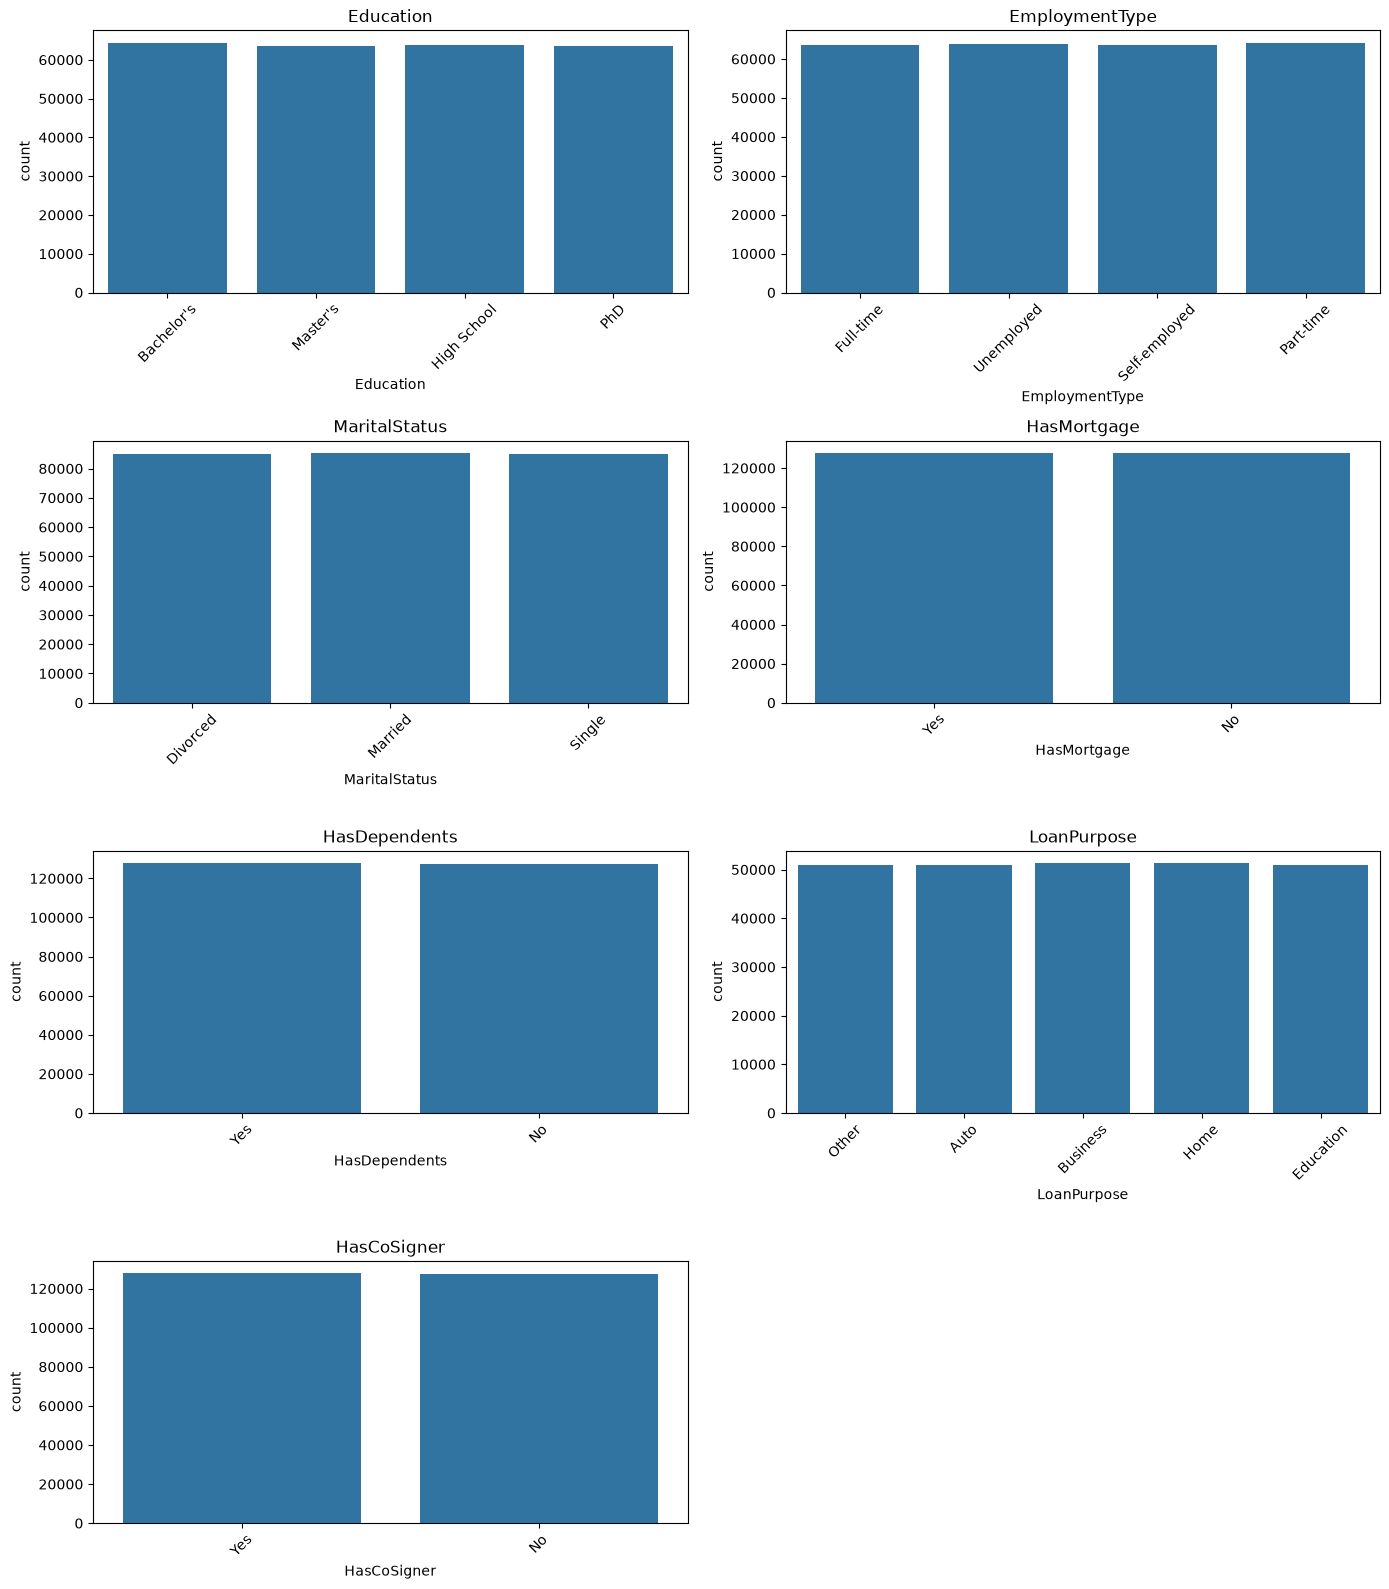

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
# remove any leftover empty subplot slots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

All categorical features are near-perfectly balanced across their categories. Each
category within Education, EmploymentType, MaritalStatus, and LoanPurpose contains
roughly equal numbers of observations. The binary columns (HasMortgage, HasDependents,
HasCoSigner) show an approximate 50/50 split. This further supports the conclusion that
this is a synthetically generated dataset. No rare categories exist, so no category
collapsing or grouping is needed before modeling.

## Data Quality Checks

In [11]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### None of the columns have any null value

In [12]:
print(df.duplicated().sum())

0


### No duplicate observations here